# CMAPSS - what the fleet looks like, all four subsets

**Arkon Manufacturing AI | Module: Time Series | Department: Engine Testing**

709 training engines and 707 test engines under six operating regimes, run to
failure. Module 01 of the Arkon platform predicts how much life each engine has
left and feeds the Quality Steering Cell through the risk event adapter.

An earlier version of this notebook explored FD001 alone, which is 13 per cent of
the rows and one regime, and two of its conclusions did not survive the move to
the fleet. Both are re-derived here from the data rather than corrected in prose.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries and the plotting style.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Assets subfolder for this module
ASSETS = 'timeseries'

# Versions are printed so a re-run years later can be compared against this one
print(f'python     {sys.version.split()[0]}')
print(f'pandas     {pd.__version__}')
print(f'numpy      {np.__version__}')
print(f'matplotlib {plt.matplotlib.__version__}')
print(f'seaborn    {sns.__version__}')

python     3.12.10
pandas     2.3.3
numpy      2.4.4
matplotlib 3.10.9
seaborn    0.13.2


## 2. Column names and the four subsets

The CMAPSS files have no header row, so the columns are named here: the engine unit, the operational cycle, three operating settings and twenty-one sensors.

In [3]:
COLUMNS = (['unit', 'cycle', 'os_1', 'os_2', 'os_3']
           + [f's{i}' for i in range(1, 22)])
SENSORS = [f's{i}' for i in range(1, 22)]
SUBSETS = ['FD001', 'FD002', 'FD003', 'FD004']

DATA_DIR = Path('../../data/01_cmapss/raw/CMaps')
assert DATA_DIR.exists(), f'Data not found: {DATA_DIR}'

print(f'{len(COLUMNS)} columns, {len(SENSORS)} sensors, {len(SUBSETS)} subsets')
print(f'data dir: {DATA_DIR} (exists: {DATA_DIR.exists()})')

26 columns, 21 sensors, 4 subsets
data dir: ..\..\data\01_cmapss\raw\CMaps (exists: True)


## 3. Load the full fleet

Four training files and four test files, read the same way. Unit numbers restart
at 1 in every file, so each engine also gets an id that is unique across the
fleet before anything is concatenated. Without it, engine 1 of FD001 and engine 1
of FD002 would be treated as one engine by every later groupby.

In [4]:
def read_subset(name, kind):
    frame = pd.read_csv(DATA_DIR / f'{kind}_{name}.txt', sep=r'\s+',
                        header=None, names=COLUMNS)
    frame['dataset'] = name
    frame['unit_uid'] = name + '_' + frame['unit'].astype(str)
    return frame


trains = {name: read_subset(name, 'train') for name in SUBSETS}
tests = {name: read_subset(name, 'test') for name in SUBSETS}

header = 'subset     train rows  train units    test rows   test units'
print(header)
print('-' * len(header))
for name in SUBSETS:
    tr, te = trains[name], tests[name]
    print(f'{name:<10}{len(tr):>11,}{tr.unit.nunique():>13}{len(te):>13,}{te.unit.nunique():>13}')

train = pd.concat(trains.values(), ignore_index=True)
test = pd.concat(tests.values(), ignore_index=True)
print('-' * len(header))
print(f'{"fleet":<10}{len(train):>11,}{train.unit_uid.nunique():>13}'
      f'{len(test):>13,}{test.unit_uid.nunique():>13}')

# The RUL files hold one number per test engine: the life left at the end of the
# recorded run. One row per test engine is the integrity check.
for name in SUBSETS:
    rul = pd.read_csv(DATA_DIR / f'RUL_{name}.txt', header=None, names=['RUL'])
    assert len(rul) == tests[name].unit.nunique(), f'RUL rows do not match engines in {name}'
print('\nRUL files: one row per test engine in all four subsets')

subset     train rows  train units    test rows   test units
------------------------------------------------------------
FD001          20,631          100       13,096          100
FD002          53,759          260       33,991          259
FD003          24,720          100       16,596          100
FD004          61,249          249       41,214          248
------------------------------------------------------------
fleet         160,359          709      104,897          707

RUL files: one row per test engine in all four subsets


## 4. Structure of the combined data

The first rows, to see the shape the four files come out as.

In [5]:
train.head()

,unit,cycle,os_1,os_2,os_3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,dataset,unit_uid
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,FD001_1


And the dtypes and row count of the combined fleet.

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 28 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   unit      160359 non-null  int64  
 1   cycle     160359 non-null  int64  
 2   os_1      160359 non-null  float64
 3   os_2      160359 non-null  float64
 4   os_3      160359 non-null  float64
 5   s1        160359 non-null  float64
 6   s2        160359 non-null  float64
 7   s3        160359 non-null  float64
 8   s4        160359 non-null  float64
 9   s5        160359 non-null  float64
 10  s6        160359 non-null  float64
 11  s7        160359 non-null  float64
 12  s8        160359 non-null  float64
 13  s9        160359 non-null  float64
 14  s10       160359 non-null  float64
 15  s11       160359 non-null  float64
 16  s12       160359 non-null  float64
 17  s13       160359 non-null  float64
 18  s14       160359 non-null  float64
 19  s15       160359 non-null  float64
 20  s16 

## 5. Missing values

Checked on the combined fleet rather than on one subset, because that is where a gap would actually appear.

In [7]:
missing = train.isnull().sum()
print('Missing values in the fleet:',
      'none' if missing.sum() == 0 else missing[missing > 0].to_dict())

Missing values in the fleet: none


## 6. Engine lifetimes across the fleet

Every training engine runs to failure, so its last cycle is its lifetime. The
spread is what makes this a variable-length problem, and it widens once the other
three subsets are present.

In [8]:
life = train.groupby(['dataset', 'unit_uid']).cycle.max()
summary = life.groupby('dataset').agg(['count', 'min', 'median', 'max']).round(0).astype(int)
summary.loc['fleet'] = [life.count(), life.min(), int(life.median()), life.max()]
print(summary.to_string())

         count  min  median  max
dataset                         
FD001      100  128     199  362
FD002      260  128     199  378
FD003      100  145     220  525
FD004      249  128     234  543
fleet      709  128     207  543

The same spread drawn, one distribution per subset.

  ✓ Saved → assets\timeseries\cmapss_eda_engine_lifetime.png


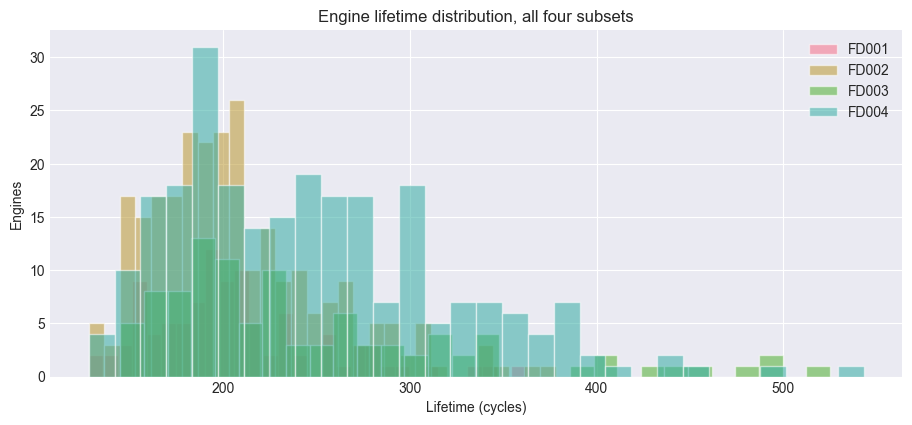

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for name in SUBSETS:
    ax.hist(life.loc[name].values, bins=30, alpha=0.55, label=name, edgecolor='white')
ax.set_xlabel('Lifetime (cycles)')
ax.set_ylabel('Engines')
ax.set_title('Engine lifetime distribution, all four subsets')
ax.legend()
save_figure(fig, 'cmapss_eda_engine_lifetime', subfolder=ASSETS)
plt.show()

## 7. Operating regimes

This is the fact FD001 cannot show. FD001 and FD003 fly one regime; FD002 and FD004 fly six. Every downstream decision about scaling follows from this table.

In [10]:
# The regime is the rounded triple of operating settings. Rounding is only safe
# if the settings really do cluster, so the spread inside each regime is measured
# before the key is trusted.
def regime_key(frame):
    return (frame.os_1.round(0).astype(int).astype(str) + '_'
            + frame.os_2.round(0).astype(int).astype(str) + '_'
            + frame.os_3.round(0).astype(int).astype(str))


train['regime'] = regime_key(train)
test['regime'] = regime_key(test)
regimes = sorted(train.regime.unique())

spread = (train.groupby('regime')[['os_1', 'os_2', 'os_3']]
          .agg(lambda s: s.max() - s.min()).max())
print(f'Operating regimes across the fleet: {len(regimes)}')
print('Largest spread of a setting inside one regime:',
      {k: round(v, 4) for k, v in spread.items()})

by_regime = train.groupby(['regime', 'dataset']).size().unstack(fill_value=0)
print()
print(by_regime.to_string())

Operating regimes across the fleet: 6
Largest spread of a setting inside one regime: {'os_1': 0.0174, 'os_2': 0.0026, 'os_3': 0.0}

dataset   FD001  FD002  FD003  FD004
regime                              
0_0_100   20631   8044  24720   9238
10_0_100      0   8096      0   9224
20_1_100      0   8122      0   9091
25_1_60       0   8002      0   9139
35_1_100      0   8037      0   9162
42_1_100      0  13458      0  15395


The regime counts drawn per subset.

  ✓ Saved → assets\timeseries\cmapss_eda_operating_regimes.png


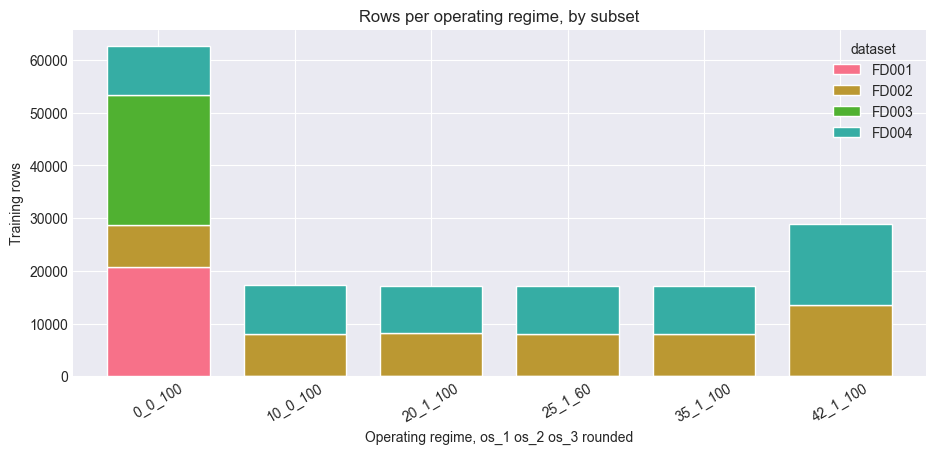

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
by_regime.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', width=0.75)
ax.set_xlabel('Operating regime, os_1 os_2 os_3 rounded')
ax.set_ylabel('Training rows')
ax.set_title('Rows per operating regime, by subset')
ax.tick_params(axis='x', rotation=30)
save_figure(fig, 'cmapss_eda_operating_regimes', subfolder=ASSETS)
plt.show()

## 8. The flat-sensor conclusion that did not survive

This project has given three different answers to the same question, and only one
of them is measured against the fleet. The cell below reproduces the FD001 rule:
variance below 0.01 over the whole subset.

In [12]:
fd001_var = trains['FD001'][SENSORS].var()
flat_fd001 = fd001_var[fd001_var < 0.01].index.tolist()

within_regime_std = train.groupby('regime')[SENSORS].std().max()
flat_fleet = [s for s in SENSORS if within_regime_std[s] < 1e-9]

print('FD001, variance below 0.01 over the whole subset :', flat_fd001)
print('Fleet, zero variance inside every regime         :', flat_fleet)
print()
print('Dropped by the FD001 rule but informative on the fleet:',
      sorted(set(flat_fd001) - set(flat_fleet)))
print()
print('Distinct values of the four constants, per subset:')
for s in flat_fleet:
    counts = {name: int(trains[name][s].nunique()) for name in SUBSETS}
    print(f'  {s:<4} {counts}')

FD001, variance below 0.01 over the whole subset : ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']
Fleet, zero variance inside every regime         : ['s1', 's5', 's18', 's19']

Dropped by the FD001 rule but informative on the fleet: ['s10', 's13', 's15', 's16', 's6', 's8']

Distinct values of the four constants, per subset:
  s1   {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}
  s5   {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}
  s18  {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}
  s19  {'FD001': 1, 'FD002': 2, 'FD003': 1, 'FD004': 2}


It flags **ten** sensors. The previous version of this notebook printed exactly
that list and then summarised it as **seven**, and `02_cmapss_preprocessing`
dropped those seven, a hand-picked set matching neither the cell above it nor the
data.

**The threshold is the flaw.** 0.01 in raw sensor units is arbitrary and depends
on each sensor's scale. Across the fleet the question has a physical answer
instead: a sensor is uninformative when it does not vary **inside** an operating
regime, because then it carries nothing but the regime code that os_1 to os_3
already carry. That test gives **four**, and it is the test the training script
uses.

## 9. Why one global scaler is wrong

The same sensor for one engine of a single-regime subset and one engine of a
six-regime subset. The second is not noise: it is the regime switching, and a
global scaler folds that step change into the degradation signal.

  ✓ Saved → assets\timeseries\cmapss_eda_sensor_degradation.png


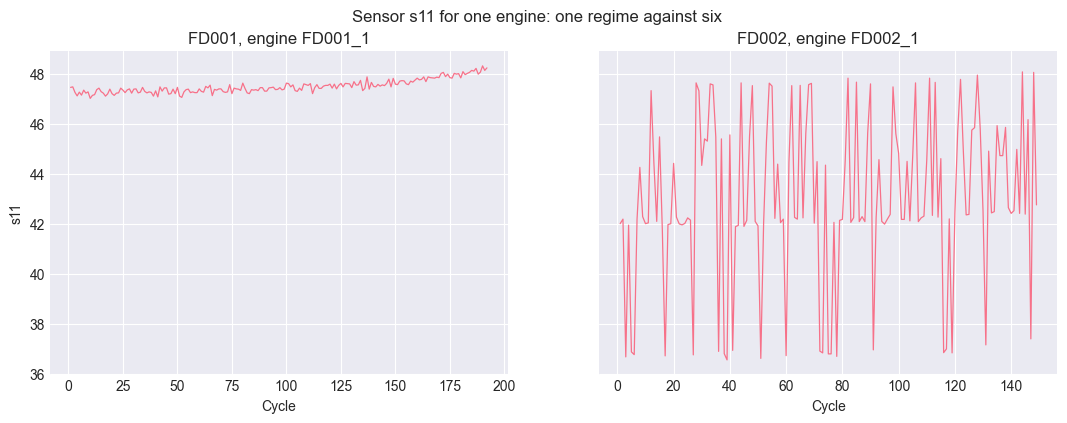

In [13]:
keep_sensors = [s for s in SENSORS if s not in flat_fleet]
sensor = 's11'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, subset in zip(axes, ['FD001', 'FD002']):
    frame = trains[subset]
    unit = frame.unit_uid.iloc[0]
    part = frame[frame.unit_uid == unit]
    ax.plot(part.cycle, part[sensor], linewidth=0.9)
    ax.set_title(f'{subset}, engine {unit}')
    ax.set_xlabel('Cycle')
axes[0].set_ylabel(sensor)
fig.suptitle(f'Sensor {sensor} for one engine: one regime against six')
save_figure(fig, 'cmapss_eda_sensor_degradation', subfolder=ASSETS)
plt.show()

## 10. Ten engines per subset, one sensor

The degradation traces themselves, so the variable-length problem is visible rather than only tabulated.

  ✓ Saved → assets\timeseries\cmapss_eda_multiengine_degradation.png


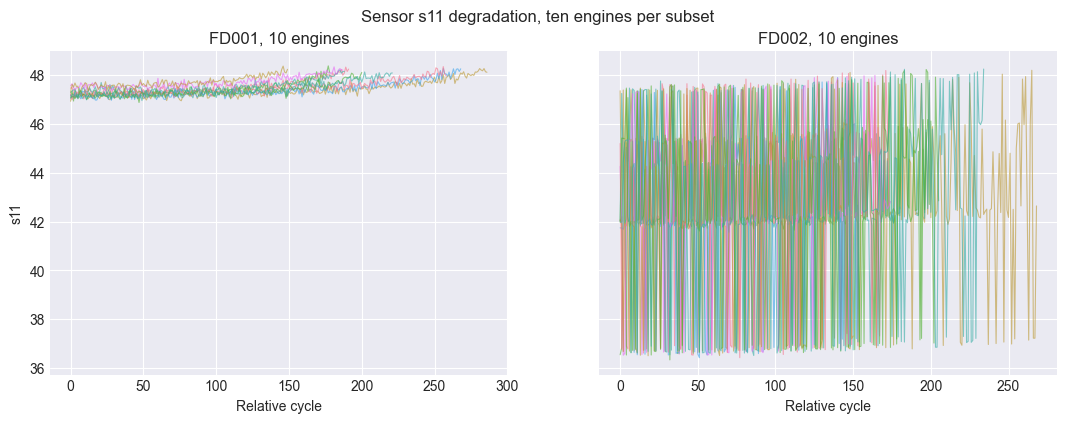

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, subset in zip(axes, ['FD001', 'FD002']):
    frame = trains[subset]
    for unit in frame.unit_uid.unique()[:10]:
        part = frame[frame.unit_uid == unit]
        ax.plot(range(len(part)), part[sensor], alpha=0.6, linewidth=0.8)
    ax.set_title(f'{subset}, 10 engines')
    ax.set_xlabel('Relative cycle')
axes[0].set_ylabel(sensor)
fig.suptitle(f'Sensor {sensor} degradation, ten engines per subset')
save_figure(fig, 'cmapss_eda_multiengine_degradation', subfolder=ASSETS)
plt.show()

## 11. Correlation among the kept sensors

Fleet-wide, to see whether the seventeen survivors are seventeen independent measurements or a smaller number repeated.

  ✓ Saved → assets\timeseries\cmapss_eda_correlation_heatmap.png


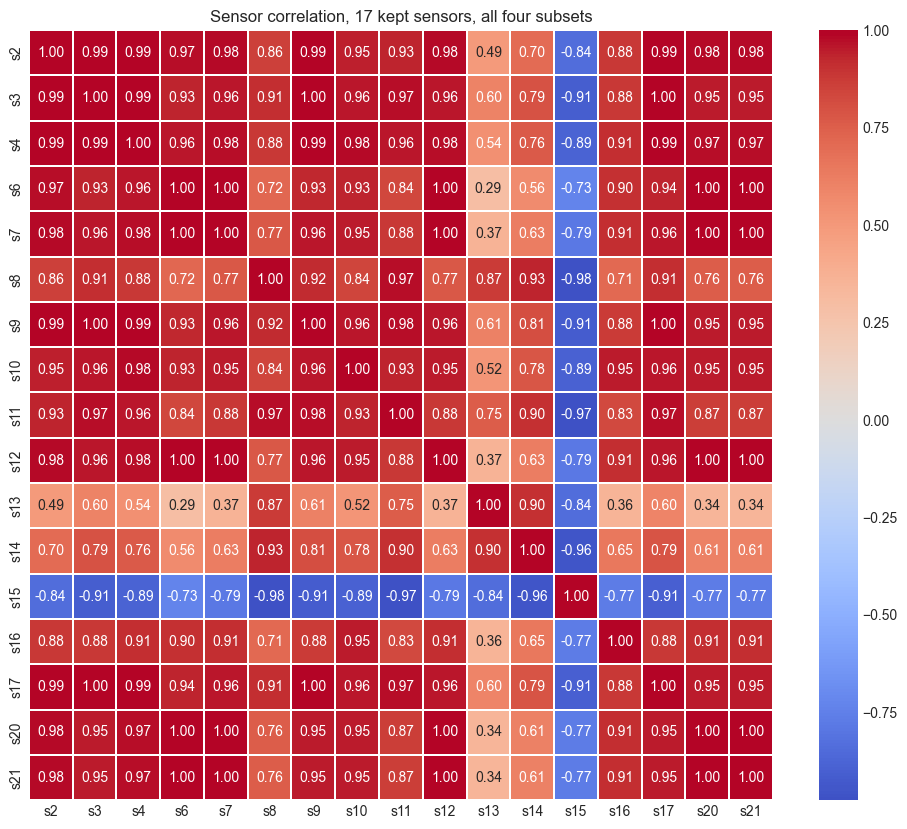

In [15]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = train[keep_sensors].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax)
ax.set_title(f'Sensor correlation, {len(keep_sensors)} kept sensors, all four subsets')
save_figure(fig, 'cmapss_eda_correlation_heatmap', subfolder=ASSETS)
plt.show()

## 12. What this notebook found

| Finding | Detail |
|---|---|
| Scope | All four subsets: 160,359 training rows, 709 training engines, 104,897 test rows, 707 test engines |
| No missing values | Confirmed on the combined fleet, not on one subset |
| Six operating regimes | FD001 and FD003 fly one, FD002 and FD004 fly six |
| Four constant sensors, not seven or ten | s1, s5, s18 and s19 have zero variance inside every regime. The FD001 rule flags ten and the earlier summary claimed seven; six of those are informative on the fleet and are kept |
| Scaling must be per regime | A sensor's level steps with the regime, so a global scaler flattens the degradation signal |
| Variable lifetime | The spread widens across the fleet, so the model must handle variable-length histories |

**Next:** `02_cmapss_preprocessing.ipynb` - RUL labels, the four sensor drops,
per-regime standardisation and the temporal window features.